# US Top 50 — Exploratory Data Analysis
Run this notebook BEFORE building the dashboard. Goal: understand the data deeply.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.preprocessing import load_clean, validate
from src.feature_engineering import enrich, build_song_stats, build_artist_stats

pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')
print('Setup complete')

Matplotlib is building the font cache; this may take a moment.


Setup complete


## 1. Load & Validate

In [2]:
df_raw = load_clean('../data/top50_us.csv')
val    = validate(df_raw)

print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw.date.min()} → {df_raw.date.max()}')
print(f'Validation report: {val}')
df_raw.head()

c:\Users\Admin\Downloads\spotify-us-top50\notebooks\..\src\preprocessing.py:73: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


Shape: (27752, 12)
Date range: 2024-05-18 00:00:00 → 2025-11-27 00:00:00
Validation report: {'missing_columns': [], 'invalid_rank_count': 0, 'duplicate_rows': 0, 'null_counts': {'date': 0, 'position': 0, 'song': 0, 'artist': 0, 'popularity': 0, 'duration_ms': 0, 'album_type': 0, 'total_tracks': 0, 'is_explicit': 0, 'album_cover_url': 0, 'song_key': 0, 'artist_key': 0}}


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,song_key,artist_key
0,2024-05-18,1,Ella Baila Sola,Eslabon Armado,89,165671,Album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...,ella baila sola,eslabon armado
1,2024-05-18,2,Last Night,Morgan Wallen,89,163854,Album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...,last night,morgan wallen
2,2024-05-18,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,Single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...,all my life (feat. j. cole),lil durk & j. cole
3,2024-05-18,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,Single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...,un x100to,grupo frontera & bad bunny
4,2024-05-18,5,Kill Bill,SZA,94,153946,Album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...,kill bill,sza


In [3]:
print('Dtypes:')
print(df_raw.dtypes)
print('\nNull counts:')
print(df_raw.isnull().sum())

Dtypes:
date               datetime64[us]
position                    Int64
song                          str
artist                        str
popularity                  int64
duration_ms                 int64
album_type                    str
total_tracks                Int64
is_explicit                  bool
album_cover_url               str
song_key                      str
artist_key                    str
dtype: object

Null counts:
date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
song_key           0
artist_key         0
dtype: int64


## 2. Feature Engineering

In [4]:
df         = enrich(df_raw)
song_stats = build_song_stats(df)
art_stats  = build_artist_stats(df)

print(f'Enriched df shape: {df.shape}')
print(f'Unique songs: {df.song_key.nunique()}')
print(f'Unique artists: {df.artist_key.nunique()}')
song_stats.head()

Enriched df shape: (27752, 20)
Unique songs: 938
Unique artists: 296


,song_key,song,artist,artist_key,album_type,is_explicit,duration_min,days_on_chart,avg_rank,best_rank,rank_volatility,avg_popularity,total_tracks,popularity_trend_score
791,something in the orange,Something in the Orange,Zach Bryan,zach bryan,Single,False,3.80,536,26.29,9,9.35,88.37,4,-0.0081
477,last night,Last Night,Morgan Wallen,morgan wallen,Album,True,2.73,492,22.61,1,14.55,85.68,36,-0.0164
414,i remember everything (feat. kacey musgraves),I Remember Everything (feat. Kacey Musgraves),Zach Bryan,zach bryan,Album,False,3.79,446,13.9,1,9.89,90.09,16,-0.0123
743,see you again (feat. kali uchis),See You Again (feat. Kali Uchis),"Tyler, The Creator","tyler, the creator",Album,True,3.01,444,29.38,4,11.81,91.09,14,-0.0168
810,stick season,Stick Season,Noah Kahan,noah kahan,Album,False,3.04,414,18.29,1,11.36,91.10,14,-0.0078


## 3. Distributions

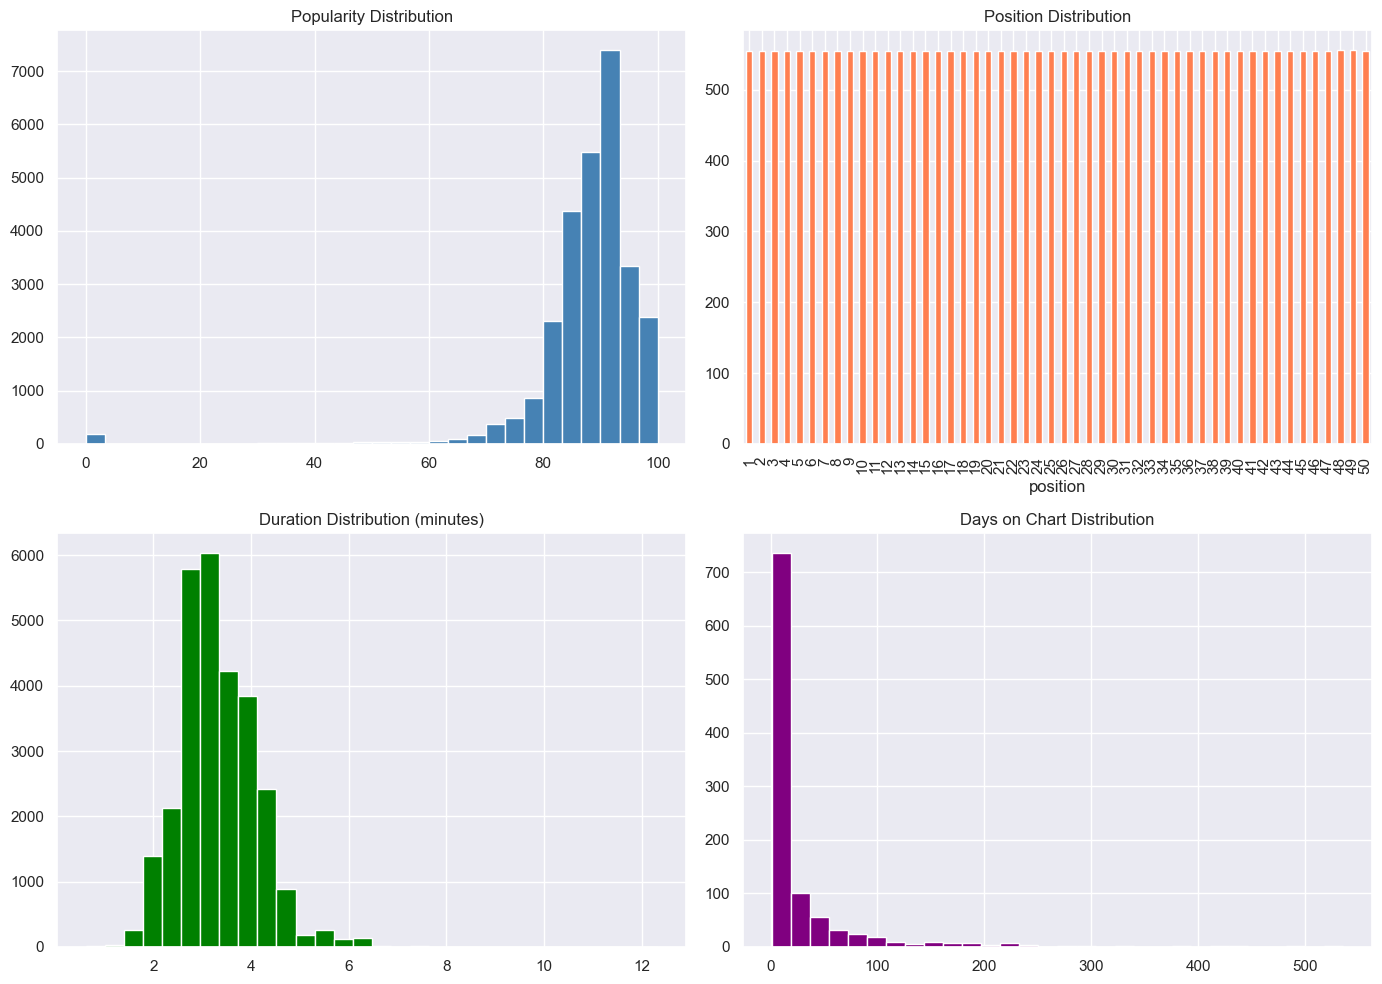

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['popularity'].hist(ax=axes[0,0], bins=30, color='steelblue')
axes[0,0].set_title('Popularity Distribution')

df['position'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Position Distribution')

df['duration_min'].hist(ax=axes[1,0], bins=30, color='green')
axes[1,0].set_title('Duration Distribution (minutes)')

song_stats['days_on_chart'].hist(ax=axes[1,1], bins=30, color='purple')
axes[1,1].set_title('Days on Chart Distribution')

plt.tight_layout()
plt.show()

## 4. Popularity vs Rank Correlation

In [6]:
corr = df[['popularity','position']].corr()
print('Correlation matrix:')
print(corr)

px.scatter(
    df.sample(3000, random_state=42),
    x='position', y='popularity',
    trendline='ols',
    title=f'Popularity vs Rank (r={corr.iloc[0,1]:.3f})',
    opacity=0.4
).show()

Correlation matrix:
            popularity  position
popularity    1.000000 -0.094442
position     -0.094442  1.000000


## 5. Top Artists

In [7]:
print('Top 15 Artists by Appearances:')
print(art_stats[['artist','total_appearances','unique_songs','dominance_index']].head(15).to_string(index=False))

Top 15 Artists by Appearances:
            artist  total_appearances  unique_songs  dominance_index
      Taylor Swift               2015            96             7.26
        Zach Bryan               1857            35             6.69
     Morgan Wallen               1669            10             6.01
 Sabrina Carpenter                967            14             3.48
             Drake                841            35             3.03
     Chappell Roan                794             6             2.86
      Travis Scott                762            31             2.75
     Billie Eilish                729            12             2.63
Tyler, The Creator                706            16             2.54
               SZA                648             3             2.33
    Olivia Rodrigo                565            18             2.04
      Benson Boone                506             3             1.82
        Noah Kahan                450             8             1.62
   

## 6. Explicit Content Analysis

In [8]:
from src.analytics import explicit_vs_clean
print(explicit_vs_clean(df))

   is_explicit  song_count   avg_rank  avg_popularity    avg_days     label
0        False         457  25.597633       87.986502  163.255070     Clean
1         True         496  25.397445       87.303570  135.259376  Explicit


## 7. Save Cleaned Data

In [9]:
df.to_csv('../data/top50_enriched.csv', index=False)
song_stats.to_csv('../data/song_stats.csv', index=False)
art_stats.to_csv('../data/artist_stats.csv', index=False)
print('All files saved.')

All files saved.
